In [1]:
!nvidia-smi

Wed Mar 25 09:15:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import keras as kr
from keras import layers
import seaborn as sb
import sklearn
import tensorflow as tf
import random as rnd
import math
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

sklearn.set_config(transform_output="pandas")

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
%cd /content/drive/My Drive/waste-clasifier/

/content/drive/My Drive/waste-clasifier


In [15]:
classes = ["cardboard", "glass", "metal", "paper", "plastic", "trash"]

In [17]:
train_csv=pd.read_csv("train/_classes.csv")
train_df=pd.DataFrame(train_csv)
#train_ppc_csv=pd.read_csv("train_preprocessed/_classes_preprocessed.csv")
#train_ppc_df=pd.DataFrame(train_ppc_csv)
test_csv=pd.read_csv("test/_classes.csv")
test_df=pd.DataFrame(test_csv)
valid_csv=pd.read_csv("valid/_classes.csv")
valid_df=pd.DataFrame(valid_csv)

y_train = train_df[classes].values
y_val = valid_df[classes].values
y_test = test_df[classes].values
train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1767 entries, 0 to 1766
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   filename   1767 non-null   object
 1   cardboard  1767 non-null   int64 
 2   glass      1767 non-null   int64 
 3   metal      1767 non-null   int64 
 4   paper      1767 non-null   int64 
 5   plastic    1767 non-null   int64 
 6   trash      1767 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 96.8+ KB


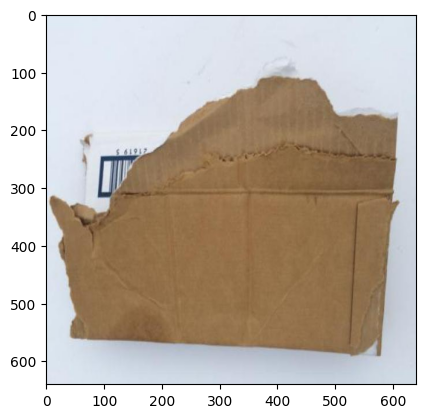

In [7]:
random_idx = rnd.randint(0, len(train_df) - 1)
img_path = os.path.join("train", train_df["filename"][random_idx])
img = mpimg.imread(img_path)
plt.imshow(img)
plt.show()

In [8]:
vis_df=pd.DataFrame({
    "train":train_df[classes].sum(),
    "test":test_df[classes].sum(),
    "valid":valid_df[classes].sum()
})
vis_df

,train,test,valid
cardboard,275,44,84
glass,352,47,102
metal,284,40,85
paper,423,64,107
plastic,340,44,96
trash,93,14,30


<Axes: xlabel='category', ylabel='count'>

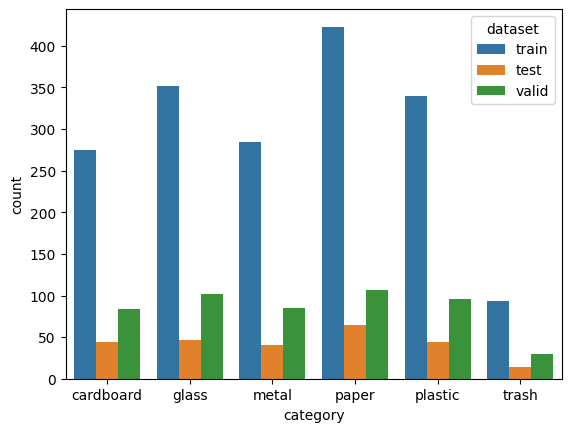

In [13]:
df_plot = vis_df.reset_index().rename(columns={'index': 'category'})
df_melted = df_plot.melt(id_vars='category', var_name='dataset', value_name='count')
sb.barplot(data=df_melted, x='category', y='count', hue='dataset')

In [18]:
datagen = ImageDataGenerator(rescale=1./255)
image_size=640
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory="train/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(image_size, image_size),
    batch_size=64,
    class_mode="raw"
)

Found 1767 validated image filenames.


In [8]:
datagen = ImageDataGenerator(rescale=1./255)
image_ppc_size=256
train_ppc_generator = datagen.flow_from_dataframe(
    dataframe=train_ppc_df,
    directory="train_preprocessed/",
    x_col=train_ppc_df.columns[0],
    y_col=classes,
    target_size=(image_ppc_size, image_ppc_size),
    batch_size=128,
    class_mode="raw"
)

Found 14136 validated image filenames.


In [19]:
v_size=640
valid_generator = datagen.flow_from_dataframe(
    dataframe=valid_df,
    directory="valid/",
    x_col=valid_df.columns[0],
    y_col=classes,
    target_size=(v_size, v_size),
    batch_size=128,
    class_mode="raw"
)

Found 504 validated image filenames.


In [20]:
t_size=640
test_generator = datagen.flow_from_dataframe(
    dataframe=test_df,
    directory="test/",
    x_col=train_df.columns[0],
    y_col=classes,
    target_size=(t_size, t_size),
    batch_size=128,
    class_mode="raw"
)

Found 253 validated image filenames.


In [21]:
from sklearn.utils.class_weight import compute_class_weight

one_hot_labels = train_df[classes].values 
print(one_hot_labels)

train_classes_int = np.argmax(one_hot_labels, axis=1)
print(train_classes_int)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_classes_int),
    y=train_classes_int
)

class_weights_dict = dict(enumerate([x for x in class_weights_array]))
print(sum(class_weights_dict))

print("Wyliczone wagi klas:", class_weights_dict)

[[0 0 0 1 0 0]
 [0 0 0 1 0 0]
 [0 0 0 1 0 0]
 ...
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]
 [1 0 0 0 0 0]]
[3 3 3 ... 0 0 0]
15
Wyliczone wagi klas: {0: np.float64(1.0709090909090908), 1: np.float64(0.8366477272727273), 2: np.float64(1.0369718309859155), 3: np.float64(0.6962174940898345), 4: np.float64(0.8661764705882353), 5: np.float64(3.1666666666666665)}


In [24]:
conv_dense=8
image_size=640
target_size=256
model=kr.Sequential(
    [
        layers.Input((image_size,image_size,3)),
        layers.RandomFlip(mode="horizontal_and_vertical"),
        layers.RandomRotation(factor=(0.0, 1.0),fill_mode='reflect',interpolation='bilinear'),
        layers.Resizing(target_size,target_size),

        layers.Conv2D(conv_dense, 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((2*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((3*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),

        layers.Conv2D((4*conv_dense), 3, strides=1, activation="softplus", use_bias=True, padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid"),
        
        layers.Flatten(),
        
        layers.Dropout(0.4),

        layers.Dense(100,activation="softplus"),
        layers.Dense(100,activation="tanh"),

        layers.Dropout(0.2),
        
        layers.Dense(6, activation="softmax")
    ]
)

model.build()
model.summary()
#kr.utils.plot_model(model, show_shapes=True)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 640, 640, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_2               │ (None, 640, 640, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 256, 256, 8)    │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256, 256, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 128, 128, 8)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 16)   │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 24)     │            96 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 32)     │         6,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 100)            │       819,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 842,142 (3.21 MB)

 Trainable params: 841,982 (3.21 MB)

 Non-trainable params: 160 (640.00 B)

In [22]:
image_size=640
target_size=256
input=layers.Input((image_size,image_size,3))
ppc1=layers.RandomFlip(mode="horizontal_and_vertical")
ppc2=layers.RandomRotation(factor=(0.0, 1.0),fill_mode='reflect',interpolation='bilinear')
ppc3=layers.Resizing(target_size,target_size)

a_0=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_1=layers.Conv2D(2, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_1=layers.Conv2D(3, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_1=layers.Conv2D(3, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_1=layers.Concatenate(axis=-1)
b_1=layers.BatchNormalization()
p_1=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_1=layers.Concatenate(axis=-1)

a_1=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")


c7_2=layers.Conv2D(2, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_2=layers.Conv2D(4, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_2=layers.Conv2D(6, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_2=layers.Concatenate(axis=-1)
b_2=layers.BatchNormalization()
p_2=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_2=layers.Concatenate(axis=-1)

a_2=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_3=layers.Conv2D(2, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_3=layers.Conv2D(5, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_3=layers.Conv2D(9, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_3=layers.Concatenate(axis=-1)
b_3=layers.BatchNormalization()
p_3=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_3=layers.Concatenate(axis=-1)

a_3=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

c7_4=layers.Conv2D(2, 7, strides=1, activation="softplus", use_bias=True, padding="same")
c5_4=layers.Conv2D(6, 5, strides=1, activation="softplus", use_bias=True, padding="same")
c3_4=layers.Conv2D(12, 3, strides=1, activation="softplus", use_bias=True, padding="same")
conc_4=layers.Concatenate(axis=-1)
b_4=layers.BatchNormalization()
p_4=layers.MaxPooling2D(pool_size=(2, 2), strides=None, padding="valid")
m_4=layers.Concatenate(axis=-1)

a_4=layers.AveragePooling2D(pool_size=(2,2), strides=None, padding="valid")

fl=layers.Flatten()

drop1=layers.Dropout(0.3)

dense1=layers.Dense(200,activation="softplus")
dense2=layers.Dense(100,activation="tanh")

drop2=layers.Dropout(0.15)
        
softmax=layers.Dense(6, activation="softmax")

In [23]:
ppc=ppc3(ppc2(ppc1(input)))
avg_0=a_0(ppc)

conv_1=conc_1([c7_1(ppc),c5_1(ppc),c3_1(ppc)])
pool_1=p_1(b_1(conv_1))
merge_1=m_1([avg_0,pool_1])
avg_1=a_1(merge_1)

conv_2=conc_2([c7_2(merge_1),c5_2(merge_1),c3_2(merge_1)])
pool_2=p_2(b_2(conv_2))
merge_2=m_2([avg_1,pool_2])
avg_2=a_2(merge_2)

conv_3=conc_3([c7_3(merge_2),c5_3(merge_2),c3_3(merge_2)])
pool_3=p_3(b_3(conv_3))
merge_3=m_3([avg_2,pool_3])
avg_3=a_3(merge_3)

conv_4=conc_4([c7_4(merge_3),c5_4(merge_3),c3_4(merge_3)])
pool_4=p_4(b_4(conv_4))
merge_4=m_4([avg_3,pool_4])
avg_4=a_4(merge_4)

flat=drop1(fl(avg_4))

post_dense=drop2(dense2(dense1(flat)))

output=softmax(post_dense)

In [24]:
model=kr.Model(inputs=input,outputs=output)
model.build((image_size,image_size,3))
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 640, 640,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_2       │ (None, 640, 640,  │          0 │ input_layer_2[0]… │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_rotation_2   │ (None, 640, 640,  │          0 │ random_flip_2[0]… │
│ (RandomRotation)    │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_2          │ (None, 256, 256,  │          0 │ random_rotation_… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_24 (Conv2D)  │ (None, 256, 256,  │        296 │ resizing_2[0][0]  │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_25 (Conv2D)  │ (None, 256, 256,  │        228 │ resizing_2[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_26 (Conv2D)  │ (None, 256, 256,  │         84 │ resizing_2[0][0]  │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_16      │ (None, 256, 256,  │          0 │ conv2d_24[0][0],  │
│ (Concatenate)       │ 8)                │            │ conv2d_25[0][0],  │
│                     │                   │            │ conv2d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         32 │ concatenate_16[0… │
│ (BatchNormalizatio… │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ average_pooling2d_… │ (None, 128, 128,  │          0 │ resizing_2[0][0]  │
│ (AveragePooling2D)  │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 8)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_17      │ (None, 128, 128,  │          0 │ average_pooling2… │
│ (Concatenate)       │ 11)               │            │ max_pooling2d_8[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 128, 128,  │      1,080 │ concatenate_17[0… │
│                     │ 2)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 128, 128,  │      1,104 │ concatenate_17[0… │
│                     │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 128, 128,  │        600 │ concatenate_17[0… │
│                     │ 6)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_18      │ (None, 128, 128,  │          0 │ conv2d_27[0][0],  │
│ (Concatenate)       │ 12)               │            │ conv2d_28[0][0],  │
│                     │                   │            │ conv2d_29[0][0] 

 Total params: 800,634 (3.05 MB)

 Trainable params: 800,522 (3.05 MB)

 Non-trainable params: 112 (448.00 B)

In [25]:
kr.utils.plot_model(model, show_shapes=True)

In [ ]:
micro_model = tf.keras.Sequential([
    layers.Input((image_size,image_size,3)),
    layers.RandomFlip(mode="horizontal_and_vertical"),
    layers.RandomRotation(factor=(0.0, 1.0),fill_mode='reflect',interpolation='bilinear'),
    layers.Resizing(target_size,target_size),
])

In [33]:
def visualize_random_augmentation(df, image_dir="."):
    """
    df: Twój pandas DataFrame
    image_dir: Ścieżka do folderu z obrazkami (jeśli w 'filename' są tylko nazwy plików)
    """
    # Losujemy jeden wiersz
    random_row = df.sample(1).iloc[0]
    img_path = os.path.join(image_dir, random_row['filename'])
    
    # Wczytujemy i dekodujemy obrazek
    img_raw = tf.io.read_file(img_path)
    img_tensor = tf.image.decode_image(img_raw, channels=3, expand_animations=False)
    
    # Upewniamy się, że to float32 i skalujemy do 640x640 (jeśli oryginał ma inny wymiar)
    img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
    img_tensor = tf.image.resize(img_tensor, [640, 640])
    
    # Dodajemy wymiar batcha: (640, 640, 3) -> (1, 640, 640, 3)
    img_batch = tf.expand_dims(img_tensor, axis=0)
    
    # Przepuszczamy przez mikro model z wymuszeniem trybu uczenia (training=True)
    augmented_batch = micro_model(img_batch, training=True)
    
    # Usuwamy wymiar batcha do wizualizacji
    augmented_img = augmented_batch[0]
    
    # Wyświetlamy wyniki
    plt.figure(figsize=(12, 6))
    
    # Oryginał
    plt.subplot(1, 2, 1)
    plt.title(f"Oryginał (640x640)\nPlik: {random_row['filename']}")
    plt.imshow(img_tensor)
    plt.axis('off')
    
    # Zaugmentowany
    plt.subplot(1, 2, 2)
    plt.title("Po Augmentacji (256x256)\nRotacja + Dynamic Crop")
    # tf.image.resize może wyrzucić wartości poza 0-1, więc dla pewności przycinamy
    plt.imshow(tf.clip_by_value(augmented_img, 0.0, 1.0)) 
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

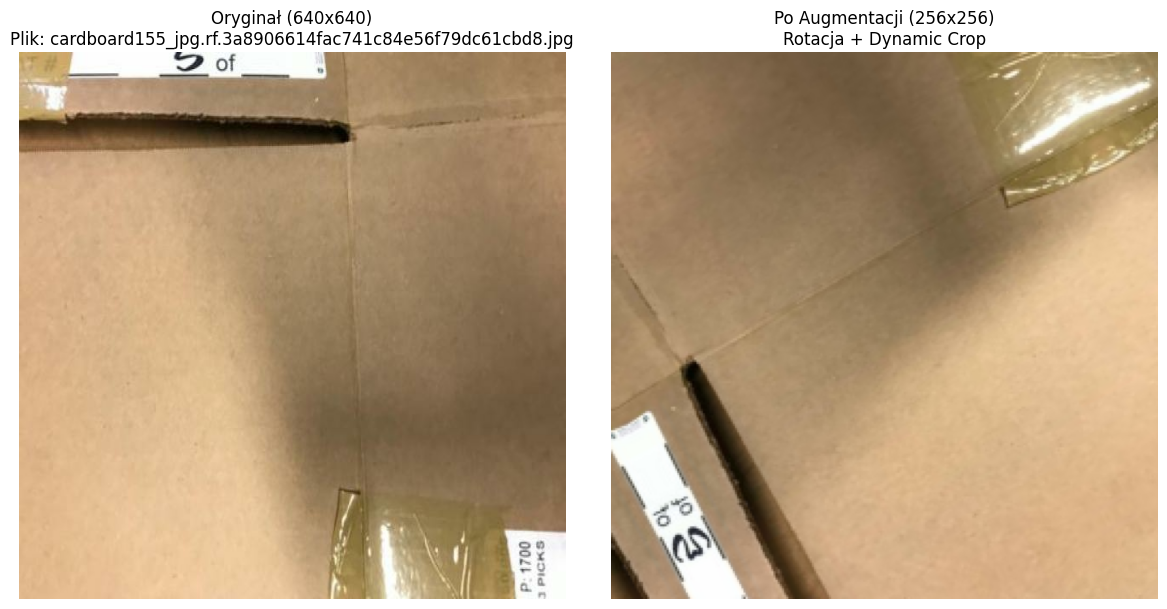

In [49]:
visualize_random_augmentation(train_df,"train")

In [14]:
def generate_offline_dataset(csv_path, source_dir, dest_dir):
    # Wczytujemy oryginalny plik CSV
    df = pd.read_csv(csv_path)
    
    # Tworzymy folder docelowy, jeśli nie istnieje
    os.makedirs(dest_dir, exist_ok=True)
    
    new_rows = []
    angles = [0, 45, 90, 135, 180, 225, 270, 315]
    
    S = 360
    target_size = 256
    
    # Środek obrazu do rotacji
    center = (S / 2, S / 2)
    
    print(f"Rozpoczynam generowanie zdjęć. Do przetworzenia: {len(df)} plików bazowych...")
    
    for index, row in df.iterrows():
        orig_filename = row['filename']
        img_path = os.path.join(source_dir, orig_filename)
        
        # Wczytanie obrazu (OpenCV wczytuje w formacie BGR, co jest ok, 
        # bo imwrite też oczekuje BGR)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Ostrzeżenie: Nie znaleziono pliku {img_path}. Pomijam.")
            continue
            
        # Upewniamy się, że obraz wejściowy ma na pewno 360x360
        if img.shape[:2] != (S, S):
            img = cv2.resize(img, (S, S), interpolation=cv2.INTER_AREA)
            
        for angle in angles:
            # 1. Obliczamy bezpieczny rozmiar boku s(theta)
            rad = math.radians(angle)
            sin_a = abs(math.sin(rad))
            cos_a = abs(math.cos(rad))
            
            # Bezpieczny rozmiar kwadratu wewnętrznego
            safe_s = int(S / (sin_a + cos_a))
            
            # 2. Rotacja
            # Przy 0 stopniach pomijamy transformację dla oszczędności czasu
            if angle != 0:
                M = cv2.getRotationMatrix2D(center, angle, 1.0)
                rotated = cv2.warpAffine(
                    img, M, (S, S), 
                    flags=cv2.INTER_LINEAR, 
                    borderMode=cv2.BORDER_CONSTANT, 
                    borderValue=(0,0,0) # Czarne rogi do odcięcia
                )
            else:
                rotated = img
                
            # 3. Dynamiczne Kadrowanie ze środka
            offset = (S - safe_s) // 2
            cropped = rotated[offset:offset+safe_s, offset:offset+safe_s]
            
            # 4. Skalowanie na docelowy 256x256
            # Ciekawostka matematyczna: dla 45 stopni safe_s wynosi ~254. 
            # Skalowanie 254 -> 256 jest bezstratne dla oka.
            final_img = cv2.resize(cropped, (target_size, target_size), interpolation=cv2.INTER_CUBIC)
            
            # 5. Zapis pliku
            name, ext = os.path.splitext(orig_filename)
            new_filename = f"{name}_rot{angle}{ext}"
            new_filepath = os.path.join(dest_dir, new_filename)
            
            cv2.imwrite(new_filepath, final_img)
            
            # 6. Dodanie informacji do nowej tabeli
            new_row = row.copy()
            new_row['filename'] = new_filename
            new_rows.append(new_row)
            
        # Prosty wskaźnik postępu
        if (index + 1) % 200 == 0:
            print(f"Przetworzono {index + 1} / {len(df)} zdjęć bazowych...")

    # Zapis nowego pliku CSV
    new_df = pd.DataFrame(new_rows)
    new_csv_path = os.path.join(dest_dir, "_classes_preprocessed.csv")
    new_df.to_csv(new_csv_path, index=False)
    
    print(f"\nGotowe! Zapisano łącznie {len(new_df)} obrazów w folderze '{dest_dir}'.")
    print(f"Nowy plik z etykietami: {new_csv_path}")

In [ ]:
visualize_random_augmentation(train_df,"train")

In [15]:
generate_offline_dataset("train/_classes.csv","train","train_preprocessed")

Rozpoczynam generowanie zdjęć. Do przetworzenia: 1767 plików bazowych...
Przetworzono 200 / 1767 zdjęć bazowych...
Przetworzono 400 / 1767 zdjęć bazowych...
Przetworzono 600 / 1767 zdjęć bazowych...
Przetworzono 800 / 1767 zdjęć bazowych...
Przetworzono 1000 / 1767 zdjęć bazowych...
Przetworzono 1200 / 1767 zdjęć bazowych...
Przetworzono 1400 / 1767 zdjęć bazowych...
Przetworzono 1600 / 1767 zdjęć bazowych...

Gotowe! Zapisano łącznie 14136 obrazów w folderze 'train_preprocessed'.
Nowy plik z etykietami: train_preprocessed/_classes_preprocessed.csv


In [13]:
model_load = kr.models.load_model(
    "mikro_model50.keras"
    #custom_objects={"full_attention_block": full_attention_block
                    #,"loss":get_sparse_weighted_loss
                    #}
)

In [14]:
model_load.summary()

NameError: name 'model_load' is not defined

In [26]:
epochs = 50
Adam = kr.optimizers.Adam(learning_rate=0.001)
r_lr=kr.callbacks.ReduceLROnPlateau(patience=2, monitor="val_accuracy",factor=0.7)
e_s=kr.callbacks.EarlyStopping(patience=10, monitor="val_accuracy")
model.compile(optimizer=Adam,loss="categorical_crossentropy",metrics =['accuracy','recall','precision'])
model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[r_lr,e_s],
    validation_data=valid_generator,
    class_weight=class_weights_dict
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 712s 25s/step - accuracy: 0.4069 - loss: 1.6266 - precision: 0.5061 - recall: 0.2586 - val_accuracy: 0.2123 - val_loss: 2.7593 - val_precision: 0.2123 - val_recall: 0.2123 - learning_rate: 0.0010
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.4776 - loss: 1.3806 - precision: 0.6188 - recall: 0.3243 - val_accuracy: 0.2123 - val_loss: 2.6712 - val_precision: 0.2123 - val_recall: 0.2123 - learning_rate: 0.0010
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.5207 - loss: 1.2340 - precision: 0.6363 - recall: 0.3792 - val_accuracy: 0.2143 - val_loss: 2.7028 - val_precision: 0.2136 - val_recall: 0.2123 - learning_rate: 0.0010
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5507 - loss: 1.1496 - precision: 0.6639 - recall: 0.4126 - val_accuracy: 0.2421 - val_loss: 2.2720 - val_precision: 0.2380 - val_recall: 0.1964 - learning_rate: 0.0010
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5563 -

In [27]:
model.evaluate(test_generator)

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 4s/step - accuracy: 0.7312 - loss: 0.8282 - precision: 0.7743 - recall: 0.6917


[0.8282024264335632, 0.731225311756134, 0.6916996240615845, 0.7743362784385681]

In [28]:
model.save('mastermind_model50.keras')

In [ ]:

"""
mastermind_model50 | accuracy: 0.7312 - loss: 0.8282 - precision: 0.7743 - recall: 0.6917
best_model50 | accuracy: 0.7233 - loss: 0.8908 - precision: 0.7816 - recall: 0.6364
big_rot_model62 | accuracy: 0.7036 - loss: 0.9047 - precision: 0.7703 - recall: 0.6364
big_rot_model50 | accuracy: 0.7154 - loss: 0.9060 - precision: 0.7740 - recall: 0.6364
holded_rot_model50 | accuracy: 0.6561 - loss: 0.9801 - precision: 0.7039 - recall: 0.5731
goat_model_50 | accuracy: 0.7352 - loss: 0.7235 - precision: 0.8128 - recall: 0.7036
too_long_model42 | accuracy: 0.5929 - loss: 1.1717 - precision: 0.7365 - recall: 0.4308
next3_model43 | accuracy: 0.6482 - loss: 1.0186 - precision: 0.7182 - recall: 0.6245
next2_model34 | accuracy: 0.6640 - loss: 1.0755 - precision: 0.7257 - recall: 0.6482
next_model38 | accuracy: 0.6719 - loss: 1.0829 - precision: 0.7124 - recall: 0.6364
thing_model38 | accuracy: 0.6561 - loss: 1.0464 - precision: 0.7182 - recall: 0.6245
gigant3_model42 | accuracy: 0.6719 - loss: 0.9546 - precision: 0.7212 - recall: 0.5929 - 256
gigant2_model38 | accuracy: 0.6087 - loss: 1.0791 - precision: 0.6837 - recall: 0.5296 - 256
gigant_model47 | accuracy: 0.6443 - loss: 0.9469 - precision: 0.7311 - recall: 0.6126 - 256
ballanced2_model47 | accuracy: 0.6522 - loss: 1.0356 - precision: 0.7436 - recall: 0.5731 - 256
ballanced_model34 | accuracy: 0.6561 - loss: 1.0261 - precision: 0.7346 - recall: 0.6126 - 128
overfitted_model23 | accuracy: 0.6245 - loss: 1.3682 - precision: 0.6565 - recall: 0.5968 - 128
mikro_model50 | accuracy: 0.6877 - loss: 0.9676 - precision: 0.7451 - recall: 0.6008 - 128
mikro_model67 | accuracy: 0.6759 - loss: 0.9928 - precision: 0.7299 - recall: 0.6087 - 128
good_model1 | accuracy: 0.2530 - loss: 2.6561 - precision: 0.2530 - recall: 0.2530 - 128
good_model2 | accuracy: 0.3439 - loss: 2.1603 - precision: 0.3798 - recall: 0.3123 - 128
bigger_good_model50 | accuracy: 0.6877 - loss: 0.9277 - precision: 0.7273 - recall: 0.6324 - 128
cnn_mini1 | accuracy: 0.2530 - loss: 1.7233 - precision: 0.0000e+00 - recall: 0.0000e+00 - 128
cnn_test1 | accuracy: 0.1779 - loss: 10.2570 - precision: 0.2003 - recall: 0.6008 - 128
cnn_test2 | accuracy: 0.1581 - loss: 6.6893 - precision: 0.2055 - recall: 0.4111 - 128
idk_model50 | accuracy: 0.5850 - loss: 1.1330 - precision: 0.7634 - recall: 0.3953 - 128
sml_model46 | accuracy: 0.6522 - loss: 0.9800 - precision: 0.7225 - recall: 0.5968 - 128
sml_model50 | accuracy: 0.6245 - loss: 1.0281 - precision: 0.7020 - recall: 0.5494 - 128






"""